<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/MSc_Project_N1217583.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# For TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For Grad-CAM
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K
import matplotlib.cm as cm

# For Image Utilities
from PIL import Image
import glob

# Connecting Drive
from google.colab import drive
drive.mount('/content/drive')
from collections import defaultdict

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
plantvillage_path = '/content/drive/MyDrive/Final Project Dataset/PlantVillage'

# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset[class_name].append(os.path.join(class_path, image_file))

# Print summary
for class_name, images in dataset.items():
    print(f"{class_name}: {len(images)} images")

Tomato__Tomato_mosaic_virus: 373 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Bacterial_spot: 2127 images
Tomato_healthy: 1591 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1976 images
Tomato__Target_Spot: 1404 images
Tomato_Early_blight: 1000 images
Potato___Late_blight: 1000 images
Pepper__bell___healthy: 1478 images
Pepper__bell___Bacterial_spot: 993 images
Potato___Early_blight: 1000 images


In [42]:
# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                dataset[class_name].append(os.path.join(class_path, image_file))

In [43]:
# Creating a dictionary to hold all image paths by class
dataset = defaultdict(list)

max_images_per_class = 600 # Example value, adjust as needed

for class_name in os.listdir(plantvillage_path):
    class_path = os.path.join(plantvillage_path, class_name)
    if os.path.isdir(class_path):
        # Creating a list to hold image files for the current class
        current_class_image_files = []
        for image_file in os.listdir(class_path):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                current_class_image_files.append(os.path.join(class_path, image_file))

        import random
        # Shuffle the list of image files for the current class
        random.shuffle(current_class_image_files)
        # Assign the shuffled and truncated list to the dataset dictionary
        dataset[class_name] = current_class_image_files[:max_images_per_class]


# summary
for class_name, images in dataset.items():
    # Use max_images_per_class in the print statement for clarity
    print(f"{class_name}: {len(images)} images (max {max_images_per_class} used)")

Tomato__Tomato_mosaic_virus: 373 images (max 600 used)
Tomato_Septoria_leaf_spot: 600 images (max 600 used)
Tomato_Bacterial_spot: 600 images (max 600 used)
Tomato_healthy: 600 images (max 600 used)
Tomato__Tomato_YellowLeaf__Curl_Virus: 600 images (max 600 used)
Tomato_Late_blight: 600 images (max 600 used)
Tomato_Leaf_Mold: 600 images (max 600 used)
Tomato_Spider_mites_Two_spotted_spider_mite: 600 images (max 600 used)
Tomato__Target_Spot: 600 images (max 600 used)
Tomato_Early_blight: 600 images (max 600 used)
Potato___Late_blight: 600 images (max 600 used)
Pepper__bell___healthy: 600 images (max 600 used)
Pepper__bell___Bacterial_spot: 600 images (max 600 used)
Potato___Early_blight: 600 images (max 600 used)


#  1. Visualizing Some Sample Images

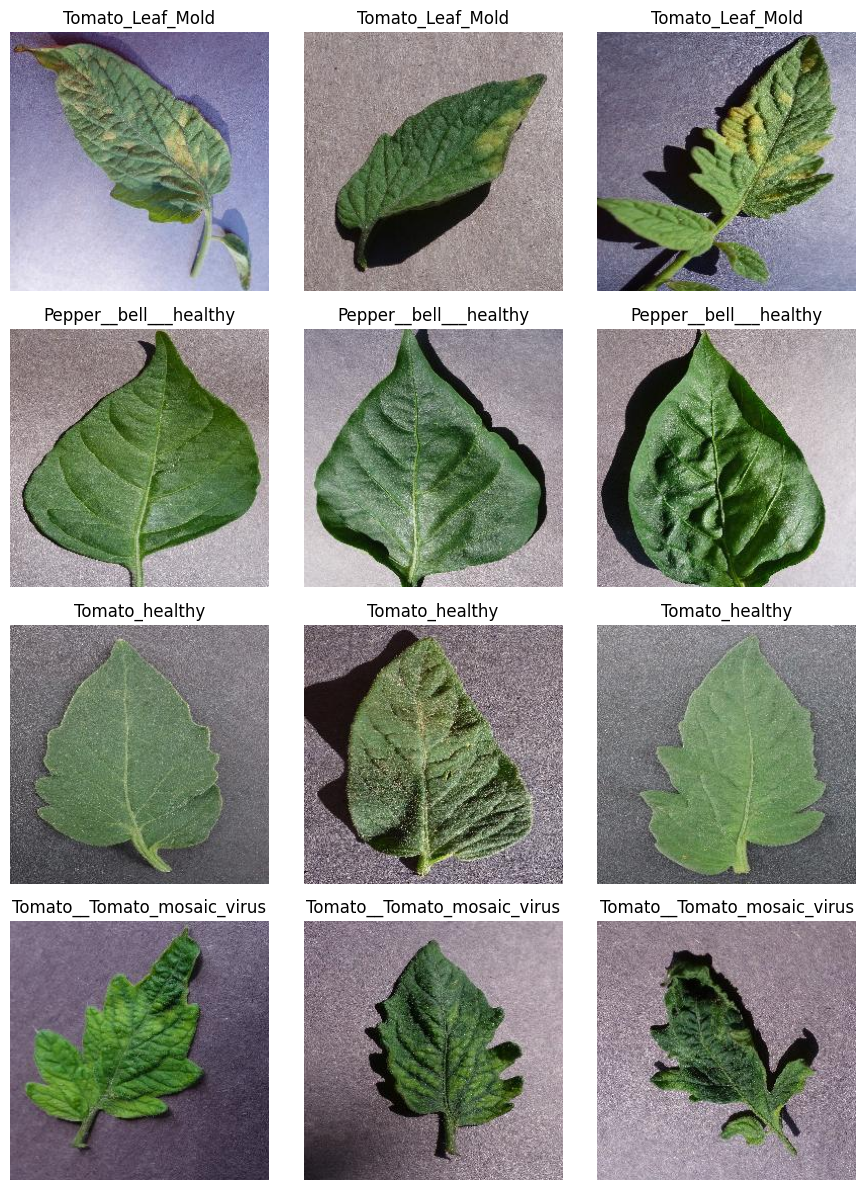

In [44]:
import matplotlib.pyplot as plt
import random

# Display sample images from random classes
def show_sample_images(dataset, num_classes=4, samples_per_class=3):
    class_names = list(dataset.keys())
    random.shuffle(class_names)
    selected_classes = class_names[:num_classes]

    plt.figure(figsize=(samples_per_class * 3, num_classes * 3))

    for i, class_name in enumerate(selected_classes):
        images = dataset[class_name]
        random.shuffle(images)
        for j in range(samples_per_class):
            img = cv2.imread(images[j])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(num_classes, samples_per_class, i * samples_per_class + j + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function
show_sample_images(dataset)

# 2. Preparing Images Paths for Train/Test Split

In [45]:
from sklearn.model_selection import train_test_split

image_paths = []
labels = []

for class_name, files in dataset.items():
    for file in files:
        image_paths.append(file)
        labels.append(class_name)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

# Split the dataset
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, encoded_labels, test_size=0.2, stratify=encoded_labels, random_state=42
)

print(f"Train samples: {len(X_train)} | Validation samples: {len(X_val)}")


Train samples: 6538 | Validation samples: 1635


# 3. Use ImageDataGenerator for Augmentation

In [46]:
# Section 3 itself doesn't produce a visible output in the form of a printed message or a plot.
# However, it performs crucial setup steps that are essential for the following sections of your code,
# particularly for handling and augmenting your image data.

# Here's what Section 3 does:

'''Imports necessary library:
It imports ImageDataGenerator from tensorflow.keras.preprocessing.image. This class is a powerful tool for augmenting image data on the fly.
Defines parameters: It defines two important parameters:

IMG_SIZE:
This sets the target size to which all images will be resized (224x224 pixels in your case). Consistent image size is required for training a CNN.
BATCH_SIZE: This determines the number of images that will be processed together in each batch during training.

Creates ImageDataGenerator instances: It creates two ImageDataGenerator objects:
1. train_datagen: This is configured with various data augmentation techniques such as rotation, shifting, zooming, and horizontal flipping. Data augmentation helps to increase the size and diversity of your training dataset, which can improve the model's generalization ability and reduce overfitting. It also includes rescale=1./255 to normalize pixel values to the range [0, 1], which is a common practice for neural networks.
2. val_datagen: This is configured only with rescale=1./255. Data augmentation is typically applied only to the training data, not the validation or test data, to ensure that the evaluation metrics are based on the original, unaltered images.
Defines a helper function (though not used directly in subsequent sections as written): It defines a function path_to_tensor. While this function is defined, the following sections use a different approach (tf.data.Dataset) for processing images, so this specific function isn't actively used in your current code flow. However, its presence suggests an alternative way you could have approached image loading if you were using the flow_from_directory method of ImageDataGenerator.

In summary, Section 3 sets up the tools (ImageDataGenerator) and parameters for image preprocessing and data augmentation, which are vital steps before feeding the images into your neural network model for training. Although it doesn't produce direct output, it lays the groundwork for the data loading and processing that happen in Section 4.'''

'''from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Helper function to load data from paths
def path_to_tensor(image_path, label):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)
    img = tf.keras.preprocessing.image.img_to_array(img)
    return img, label'''


'from tensorflow.keras.preprocessing.image import ImageDataGenerator\n\n# Define parameters\nIMG_SIZE = (224, 224)\nBATCH_SIZE = 32\n\n# Create data generators\ntrain_datagen = ImageDataGenerator(\n    rescale=1./255,\n    rotation_range=20,\n    width_shift_range=0.2,\n    height_shift_range=0.2,\n    zoom_range=0.2,\n    horizontal_flip=True\n)\n\nval_datagen = ImageDataGenerator(rescale=1./255)\n\n# Helper function to load data from paths\ndef path_to_tensor(image_path, label):\n    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMG_SIZE)\n    img = tf.keras.preprocessing.image.img_to_array(img)\n    return img, label'

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation set
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Train generator
train_generator = train_datagen.flow_from_directory(
    # Use the correct path to your dataset on Google Drive
    '/content/drive/MyDrive/Final Project Dataset/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    # Use the correct path to your dataset on Google Drive
    '/content/drive/MyDrive/Final Project Dataset/PlantVillage',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Number of classes
num_classes = len(train_generator.class_indices)

Found 16631 images belonging to 14 classes.
Found 4151 images belonging to 14 classes.


# 4. Creating TensorFlow Dataset from Paths

In [48]:
# Handles Data Loading Efficiently: Instead of loading all images into memory at once (which can be problematic for large datasets), this section creates a TensorFlow Dataset object. This object can efficiently load and process images on the fly as needed during training.

import tensorflow as tf

# Creating a TensorFlow Dataset object from image paths and labels
def process_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

# Wraping in tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

train_ds = train_ds.map(process_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 5. Building CNN Model (EfficientNetB0-based)

In [49]:
'''from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input

# Define model
def build_model(num_classes):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base

    inputs = Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_model(num_classes=len(le.classes_))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()'''

"from tensorflow.keras.applications import EfficientNetB0\nfrom tensorflow.keras.models import Model\nfrom tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input\n\n# Define model\ndef build_model(num_classes):\n    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))\n    base_model.trainable = False  # Freeze base\n\n    inputs = Input(shape=(224, 224, 3))\n    x = base_model(inputs, training=False)\n    x = GlobalAveragePooling2D()(x)\n    x = Dropout(0.3)(x)\n    outputs = Dense(num_classes, activation='softmax')(x)\n\n    model = Model(inputs, outputs)\n    return model\n\nmodel = build_model(num_classes=len(le.classes_))\nmodel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])\n\nmodel.summary()"

In [50]:
# SECTION 5: Building CNN model (EfficientNetB0-based)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Load EfficientNetB0 without top layer, with pretrained ImageNet weights
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Freeze first 100 layers to retain useful ImageNet features, fine-tune rest
for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers[100:]:
    layer.trainable = True

# Adding custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)

# Getting the number of classes from the fitted LabelEncoder
num_classes = len(le.classes_)


predictions = Dense(num_classes, activation='softmax')(x)  # Final layer

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              # Change the loss function to 'sparse_categorical_crossentropy'
              # to match the sparse integer labels.
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Set up EarlyStopping to prevent overfitting and unnecessary training
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training model

'''history = model.fit(
    train_ds, # Use the TensorFlow Dataset
    validation_data=val_ds, # Use the TensorFlow Dataset
    epochs=30,
    callbacks=[early_stop]
)'''

'history = model.fit(\n    train_ds, # Use the TensorFlow Dataset\n    validation_data=val_ds, # Use the TensorFlow Dataset\n    epochs=30,\n    callbacks=[early_stop]\n)'

# 6. Training the Model

In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_accuracy', mode='max')
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

# Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1750 - loss: 2.4769

205/205 ━━━━━━━━━━━━━━━━━━━━ 2173s 9s/step - accuracy: 0.1754 - loss: 2.4759 - val_accuracy: 0.0728 - val_loss: 2.6509
Epoch 2/20
204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4307 - loss: 1.7238

205/205 ━━━━━━━━━━━━━━━━━━━━ 71s 153ms/step - accuracy: 0.4311 - loss: 1.7226 - val_accuracy: 0.1761 - val_loss: 2.3710
Epoch 3/20
204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5516 - loss: 1.3188

205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 132ms/step - accuracy: 0.5518 - loss: 1.3184 - val_accuracy: 0.4330 - val_loss: 1.6540
Epoch 4/20
204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6322 - loss: 1.0852

205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - accuracy: 0.6323 - loss: 1.0849 - val_accuracy: 0.4697 - val_loss: 1.7515
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 149ms/step - accuracy: 0.6756 - loss: 0.9697 - val_accuracy: 0.3187 - val_loss: 2.3776
Epoch 6/20
204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6959 - loss: 0.8889

205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 128ms/step - accuracy: 0.6960 - loss: 0.8887 - val_accuracy: 0.5890 - val_loss: 1.1898
Epoch 7/20
204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7211 - loss: 0.8007

205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 127ms/step - accuracy: 0.7212 - loss: 0.8006 - val_accuracy: 0.6618 - val_loss: 1.0493
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 40s 122ms/step - accuracy: 0.7460 - loss: 0.7568 - val_accuracy: 0.2985 - val_loss: 2.6085
Epoch 9/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 47s 154ms/step - accuracy: 0.7651 - loss: 0.6944 - val_accuracy: 0.5089 - val_loss: 1.5825
Epoch 10/20
204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7653 - loss: 0.6740

205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 129ms/step - accuracy: 0.7654 - loss: 0.6739 - val_accuracy: 0.6685 - val_loss: 1.0799
Epoch 11/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 29s 128ms/step - accuracy: 0.7954 - loss: 0.6093 - val_accuracy: 0.5670 - val_loss: 1.5834
Epoch 12/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step - accuracy: 0.8142 - loss: 0.5749 - val_accuracy: 0.2239 - val_loss: 3.3813


In [52]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.6510 - loss: 1.0448
Validation Loss: 1.0493
Validation Accuracy: 0.6618


# 7. Plot Accuracy & Loss Curves

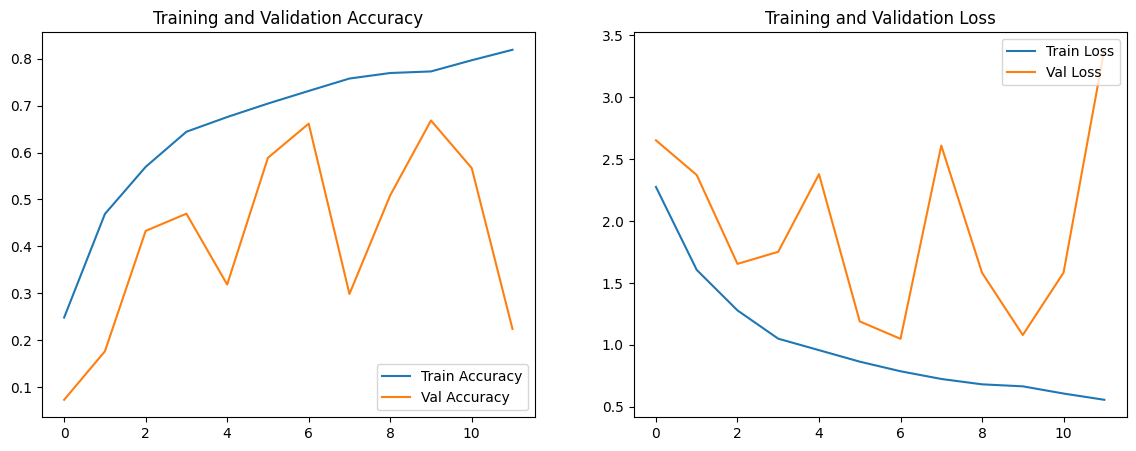

In [53]:
import matplotlib.pyplot as plt

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_training(history)

# Grad-CAM Visualization

In [54]:
# Loading the Trained Model:
model = load_model('/content/best_model.h5')

# Choosing the PreProcessing Sample Image

In [55]:
# Loading and preprocess an image (update path)

img_path = '/content/drive/MyDrive/IMG_20191216_155825.jpg'
img_size = (224, 224)

img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Creating a Grad-CAM Heatmap Function

In [56]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Grad-CAM Heatmap and Overlay on Original Image function

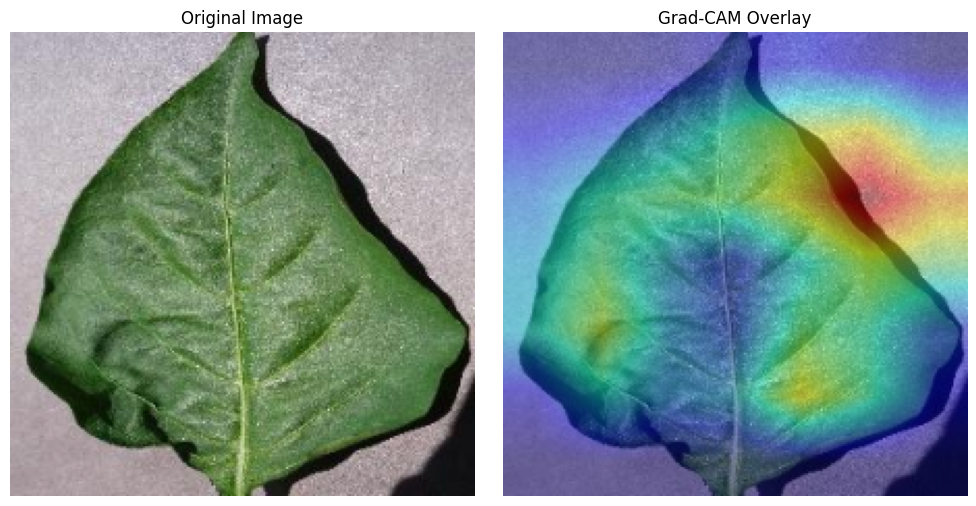

"# Get the base model (EfficientNetB0) from your loaded model\nbase_model = model.get_layer('efficientnetb0')\n\n# Check the last convolutional layer name inside base_model\nfor layer in base_model.layers:\n    if 'conv' in layer.name:\n        print(layer.name)\n\n# Use the correct final convolutional layer name\nlast_conv_layer_name = 'top_conv'\n\n\ndef make_gradcam_heatmap(img_array, full_model, base_model, last_conv_layer_name, pred_index=None):\n    # Get intermediate conv output + full model output\n    grad_model = tf.keras.models.Model(\n        [full_model.inputs],\n        [base_model.get_layer(last_conv_layer_name).output, full_model.output]\n    )\n\n    with tf.GradientTape() as tape:\n        conv_outputs, predictions = grad_model(img_array)\n        if pred_index is None:\n            pred_index = tf.argmax(predictions[0])\n        class_channel = predictions[:, pred_index]\n\n    grads = tape.gradient(class_channel, conv_outputs)\n    pooled_grads = tf.reduce_mean(grad

In [62]:
# Generating Heatmap and Overlay on Original Image

# Path to image
img_path = '/content/drive/MyDrive/Final Project Dataset/PlantVillage/Pepper__bell___healthy/00100ffa-095e-4881-aebf-61fe5af7226e___JR_HL 7886.JPG'

# Load and preprocess image using cv2 for easier heatmap overlay later
img = cv2.imread(img_path)
# Ensure img is not None (check if image loading was successful)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")

img = cv2.resize(img, (224, 224))  # use your model's input size
# Expand dimensions and normalize for the model
img_array = np.expand_dims(img / 255.0, axis=0)

last_conv_layer_name = 'top_conv'

# Redefine the make_gradcam_heatmap function to work with the full model
# and the target layer name directly within the full model.
def make_gradcam_heatmap(img_array, full_model, target_layer_name, pred_index=None):
    # Getting the output of the target layer and the final model output
    grad_model = tf.keras.models.Model(
        [full_model.inputs],
        [full_model.get_layer(target_layer_name).output, full_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            # Finding the predicted class index
            pred_index = tf.argmax(predictions[0])
        # Getting the score for the predicted class
        class_channel = predictions[:, pred_index]

    # Computing the gradient of the predicted class score with respect to the convolutional layer output
    grads = tape.gradient(class_channel, conv_outputs)
    # Average the gradients over spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the convolutional layer output by the average gradient for that channel
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to the heatmap and normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Generate heatmap
# Call the make_gradcam_heatmap function with the correct layer name
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Resize and color the heatmap
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# Superimpose
# Convert img to float for calculation if it's not already
img_float = img.astype(np.float32)

# Overlay the heatmap on the original image
# Adjust the alpha values (0.4 and 0.6) to control transparency
superimposed_img = heatmap_colored * 0.4 + img_float * 0.6
# Clip values to the valid range [0, 255] and convert back to uint8
superimposed_img = np.uint8(np.clip(superimposed_img, 0, 255))

# Plot original and overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

# Thank you

In [63]:
'''def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()'''

In [64]:
'''# Path to image
img_path = '/content/drive/MyDrive/IMG_20191216_155825.jpg'

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))  # use your model's input size
img_array = np.expand_dims(img / 255.0, axis=0)

# Get the EfficientNetB0 layer from the loaded model
efficientnet_layer = model.get_layer('efficientnetb0')

# Find the name of the last convolutional layer *within* the efficientnet_layer
last_conv_layer_name = None
# Iterate through the layers inside the efficientnet_layer from the end
for layer in reversed(efficientnet_layer.layers):
    if 'conv' in layer.name:
        last_conv_layer_name = layer.name
        print(f"Found last convolutional layer within efficientnetb0: {last_conv_layer_name}")
        break # Stop once the last one is found

if last_conv_layer_name is None:
    raise ValueError("Could not find a convolutional layer within the 'efficientnetb0' layer.")

# Define the make_gradcam_heatmap function
# This function needs the *full model* and the *name* of the target layer within the full model.
def make_gradcam_heatmap(img_array, full_model, target_layer_name, pred_index=None):
    # Find the target layer's output within the full model
    grad_model = tf.keras.models.Model(
        [full_model.inputs],
        [full_model.get_layer('efficientnetb0').get_layer(target_layer_name).output, full_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Generate heatmap
# Call the make_gradcam_heatmap function with the correct layer name
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Resize and color the heatmap
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# Superimpose
superimposed_img = heatmap_colored * 0.4 + img
superimposed_img = np.uint8(superimposed_img)

# Plot original and overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()'''

ValueError: No such layer: efficientnetb0. Existing layers are: ['input_layer_1', 'rescaling_2', 'normalization_1', 'rescaling_3', 'stem_conv_pad', 'stem_conv', 'stem_bn', 'stem_activation', 'block1a_dwconv', 'block1a_bn', 'block1a_activation', 'block1a_se_squeeze', 'block1a_se_reshape', 'block1a_se_reduce', 'block1a_se_expand', 'block1a_se_excite', 'block1a_project_conv', 'block1a_project_bn', 'block2a_expand_conv', 'block2a_expand_bn', 'block2a_expand_activation', 'block2a_dwconv_pad', 'block2a_dwconv', 'block2a_bn', 'block2a_activation', 'block2a_se_squeeze', 'block2a_se_reshape', 'block2a_se_reduce', 'block2a_se_expand', 'block2a_se_excite', 'block2a_project_conv', 'block2a_project_bn', 'block2b_expand_conv', 'block2b_expand_bn', 'block2b_expand_activation', 'block2b_dwconv', 'block2b_bn', 'block2b_activation', 'block2b_se_squeeze', 'block2b_se_reshape', 'block2b_se_reduce', 'block2b_se_expand', 'block2b_se_excite', 'block2b_project_conv', 'block2b_project_bn', 'block2b_drop', 'blo

In [61]:
# Generate Heatmap and Overlay on Original Image

# Path to image
img_path = '/content/drive/MyDrive/IMG_20191216_155825.jpg'

# Load and preprocess image using cv2 for easier heatmap overlay later
img = cv2.imread(img_path)
# Ensure img is not None (check if image loading was successful)
if img is None:
    raise FileNotFoundError(f"Image not found at path: {img_path}")

img = cv2.resize(img, (224, 224))  # use your model's input size
# Expand dimensions and normalize for the model
img_array = np.expand_dims(img / 255.0, axis=0)


# Find the name of the last convolutional layer within the loaded model
# Iterate through all layers in the model from the end
last_conv_layer_name = None
for layer in reversed(model.layers):
    # Check if the layer type is convolutional (Conv2D) and not a padding layer
    if isinstance(layer, tf.keras.layers.Conv2D) and 'conv' in layer.name and 'pad' not in layer.name:
        last_conv_layer_name = layer.name
        print(f"Found last convolutional layer: {last_conv_layer_name}")
        break # Stop once the last one is found

if last_conv_layer_name is None:
    raise ValueError("Could not find a convolutional layer in the loaded model.")


# Generate heatmap
# Call the make_gradcam_heatmap function with the correct layer name
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Resize and color the heatmap
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# Superimpose
# Convert img to float for calculation if it's not already
img_float = img.astype(np.float32)

superimposed_img = heatmap_colored * 0.4 + img_float * 0.6 # Adjust transparency as needed
superimposed_img = np.uint8(np.clip(superimposed_img, 0, 255)) # Clip values to 0-255

# Plot original and overlay
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM Overlay")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

Found last convolutional layer: top_conv


TypeError: make_gradcam_heatmap() missing 1 required positional argument: 'last_conv_layer_name'